In [24]:
import matplotlib.pyplot as plt
import copy
import glob
from pathlib import Path
import os
import numpy as np
import itertools

#from pathml.slide import Slide #This doesn't seem to work --> why?
from pathml.core import HESlide, Tile, types
from pathml.utils import plot_mask, RGB_to_GREY
# from pathml.datasets.utils import download_from_url
from pathml.preprocessing import (
    BoxBlur, GaussianBlur, MedianBlur,
    NucleusDetectionHE, StainNormalizationHE, SuperpixelInterpolation,
    ForegroundDetection, TissueDetectionHE, BinaryThreshold,
    MorphClose, MorphOpen
)
import tifffile
# pn=Path('/mnt/c/Users/isettb/OneDrive - University of Pittsburgh/data/svs_examples/')
# pn = Path('/mnt/data/biliseq_he_class/raw/bile_ducts_pos/')
pn = Path('/mnt/data/biliseq_he_class/raw/new_data_20220829')

if pn.exists() == True:
    print('Good to go!')
else:
    print('Can''t find that path')
fontsize = 14

Good to go!


In [31]:
files = glob.glob(str(pn) + '/*.svs')
for f in files[0:5]:
    print(f)
pn_tiles = pn.joinpath('Tiles')
if pn_tiles.exists() == False:
    os.mkdir(pn_tiles)

# wsi = HESlide(pn.joinpath('1007477.svs').__str__())
wsi = HESlide(str(pn.joinpath('PHS16-15556 - 1010617.svs')))
# wsi_large = HESlide(pn.joinpath('CMU-1.svs').__str__())
region = wsi.slide.extract_region(location = (30080,14120), size = (1000, 1000))

def smalltile():
    # convenience function to create a new tile
    return Tile(region, coords = (0, 0), name = "testregion", slide_type = types.HE)

region2 = wsi.slide.extract_region(location = (30080,14120), size = (2000, 2000))
def smallslide():
    # convenience function to create a new tile
    return HESlide(region2, name = "testslide", slide_type = types.HE)

/mnt/data/biliseq_he_class/raw/new_data_20220829/PHS18-12242 - 1013863.svs
/mnt/data/biliseq_he_class/raw/new_data_20220829/PHS19-2477 - 1014035.svs
/mnt/data/biliseq_he_class/raw/new_data_20220829/PHS18-21346 - 1013847.svs
/mnt/data/biliseq_he_class/raw/new_data_20220829/PHS15-4221 - 1011635.svs
/mnt/data/biliseq_he_class/raw/new_data_20220829/PHS15-9836 - 1007828.svs


# Examine issue with PHS16-15556 - 1010617.svs that throws errors
Curious if using generator .\_\_next__() method will allow some form of error handling / tile skipping

__Followup: It's not possible__

In [15]:
tiles = wsi.generate_tiles(shape=5000,pad=False) #Larger tiles than problem area but curious if possible to drop
ok = True
i = 0
while ok:
    # print(i)
    if i % 100 == 0:
        print(i)
    try:
        t = tiles.__next__()
    except:
        ok = False
        print('Tile %d corrupt. Attempting to continue 1 step:' % i) 
        t = tiles.__next__() #Fun fact: it's not possible. Tile 131 is corrupt and not able to skip through generator (?)
    i=i+1

0
100
Tile 131 corrupt. Attempting to continue 1 step:


StopIteration: 

# Example of applying PathML transforms like blur

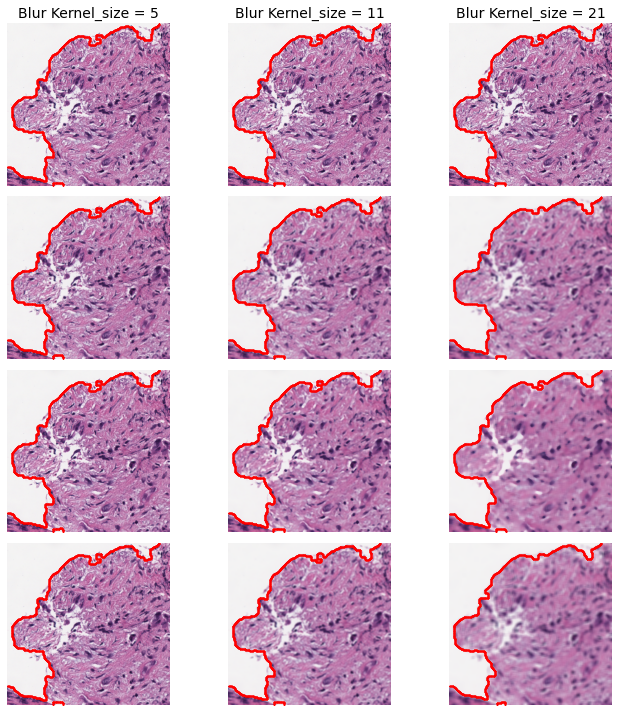

In [3]:
#Normalize, blur, tissue detect
blurs = ["Original Image", GaussianBlur, MedianBlur, BoxBlur]
blur_name = ["Original Image", "GaussianBlur", "MedianBlur", "BoxBlur"]
k_size = [5, 11, 21]
fig, axarr = plt.subplots(nrows=4, ncols=3, figsize=(10, 10))
normalizer = StainNormalizationHE(target = "normalize", stain_estimation_method = "macenko")
tissue_detector = TissueDetectionHE(mask_name = "tissue", 
                                    outer_contours_only=True,
                                   threshold = 20) 
for i, blur in enumerate(blurs):
    for j, kernel_size in enumerate(k_size):
        tile = smalltile()
        # normalizer.apply(tile)
        if blur != "Original Image":
            b = blur(kernel_size = kernel_size)
            b.apply(tile)
        tissue_detector.apply(tile)
        ax = axarr[i, j]
        #ax.imshow(tile.image)
        plot_mask(im = tile.image, mask_in=tile.masks["tissue"], ax = ax)
        if i == 0:
            ax.set_title(f"Blur Kernel_size = {kernel_size}", fontsize=fontsize)  
        if j == 0:
            ax.set_ylabel(blur_name[i], fontsize = fontsize)        
for a in axarr.ravel():
    a.set_xticks([])
    a.set_yticks([])
plt.tight_layout()
plt.show() 

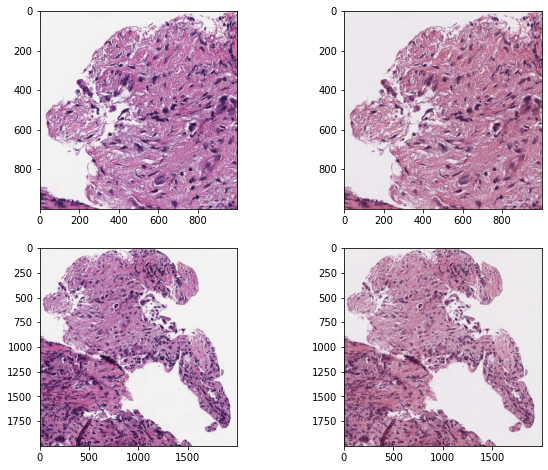

In [38]:
normalizer = StainNormalizationHE(target = "normalize", stain_estimation_method = "macenko")
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(2,2,1)
ax.imshow(region)

ax = fig.add_subplot(2,2,2)
im = normalizer.F(region)
ax.imshow(im)


ax = fig.add_subplot(2,2,3)
ax.imshow(region2)

ax = fig.add_subplot(2,2,4)
im = normalizer.F(region2)
ax.imshow(im)

In [ ]:
#Apply transforms to whole slide:
#Normalize, blur, tissue detect
# blurs = ["Original Image", GaussianBlur, MedianBlur, BoxBlur]
# k_size = [5, 11, 21]
fig, axarr = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
a=[]
for i in range(0,5):
    for j in range(0,4):
        a.append([i,j])

tiles=wsi.generate_tiles(shape=500,pad=False)
normalizer = StainNormalizationHE(target = "normalize", stain_estimation_method = "macenko")
tissue_detector = TissueDetectionHE(mask_name = "tissue", 
                                    outer_contours_only=True,
                                    blur_ksize=21,
                                    threshold= 20) 

b = MedianBlur(kernel_size = 21)
wsi_small =  smallslide()
for i,tile in enumerate(wsi_small.generate_tiles(shape=500,pad=False)):
    ax =axarr[a[i][0]][a[i][1]]
    orig_img=np.array(tile.image)
    
    tissue_detector.apply(tile)
    plot_mask(im = orig_img, mask_in=tile.masks["tissue"], ax = ax)
    
    tissue_mask=tile.masks['tissue']
    tot=127 * tissue_mask.shape[0] * tissue_mask.shape[1]
    per = 100 * np.sum(tissue_mask) / tot
    
    ax.set_title('%2.1f%% tisue' % per)
    

In [ ]:
output=pn.joinpath('Tiles')
tiss_thresh = 50;
use = wsi_large
for i,tile in enumerate(use.generate_tiles(shape=500,pad=False)):

    orig_img=np.array(tile.image)
    
    tissue_detector.apply(tile)
    
    tissue_mask=tile.masks['tissue']
    tot=127 * tissue_mask.shape[0] * tissue_mask.shape[1]
    per = 100 * np.sum(tissue_mask) / tot
    temp='%06.0fx_%06.0fy.tif' % tile.coords
    if per > tiss_thresh:        
        fn=output.joinpath('inc',temp)        
        tifffile.imwrite(fn,orig_img, photometric='rgb')
        print(fn)
    else:
        t= np.random.uniform()
        if t > 0.9: #Keep random 10% of exlcuded to see what's there
            fn=output.joinpath('exc',temp)
            tifffile.imwrite(fn,orig_img, photometric='rgb')
            # print(fn)

#         imwrite(fn,orig_img, photometric='rgb')

In [147]:
np.random.uniform()

0.2752154686575885